# Comparison of Barnes-Hut and Fast Multipole Methods against Direct Summation to Evaluate Potential Energy with Given Potential Kernels (Focus On Electrostatics / Coloumb Potential)

This report compares three ways to compute sums of pairwise interactions between charges in the context of calculating a system's potential energy. Direct summation, the Barnes-Hut Method (BHM) and Fast Multipole Method (FMM) are those which are examined. This report was conducted on a modest personal commercially available laptop and the conclusion of this report will bear this in mind, focusing on the optimal methods to solve these problems on this level of hardware. The theoretical asympotics have been proven elsewhere, but it is important to analyse whether the alternative methods are relevant in practical situations, as opposed to what may be an unrealistic crossover point.

A reciprocal distance kernel $ \frac{1}{|\mathbf{r}-\mathbf{r'}|} $ is chosen as the main focus of this report due to the well established multipole expansion methodsfor this kernel, which naturally lends itself to the calculation of electrostatic potential energy governed by the Couloumb potential, though comments are made on other kernels later in the report.

The direct method evaluates the kernel for every unordered pair of charges exactly once. If there are `N` charges, there are `N(N-1)/2` distinct pairs, so the direct method has runtime `O(N^2)` even when the inner arithmetic is vectorised.

BHM builds a spatial tree of the point set. Nearby groups are opened and evaluated in more detail, while sufficiently far-away groups are replaced by a single aggregate at their centre of mass. The parameter `theta` controls this opening criterion: smaller `theta` gives more exact local work and usually better accuracy, while larger `theta` accepts more group approximations. In balanced spatial trees, each charge interacts with only a logarithmic number of tree levels/groups on average, so the expected runtime is often `O(N log N)`; the worst case can still be worse if the tree is highly unbalanced or if the opening criterion forces many nodes to be opened.

FMM also uses a spatial hierarchy, but it represents far-field groups using multipole expansions rather than just a centre-of-mass monopole approximation. Higher expansion order includes more moment terms and can improve accuracy at extra cost. A full optimized FMM passes multipole information between tree levels and can achieve approximately `O(N)` runtime for fixed accuracy/order because each box interacts with a bounded number of well-separated boxes. The implementation here is a simplified point-to-tree multipole approximation, so it demonstrates the principle but may not achieve ideal FMM scaling. For this reason `O(N log N)` may be a more reasonable ex-ante expectation.


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from time import perf_counter


Both BHM and FMM rely on the consideration of "far" particles as an aggregated centre of mass. This makes BHM and FMM well suited to computations involving many particles gathering around a few clusters. For this reason, we take the following design. `k` "origin points" are placed on a 1 by 1 2D square (2D is chosen for computational simplicity and ease of visualization; the ideas discussed and investigated in this report can be easily generalized to 3D and the number of dimensions does not impact the analysis of the behaviour of these methods scaling with `N`). The positions of these particles are uniformly distributed accross the square. Then `n` (not to be confused with `N = k*n`) further secondary points are produced per "origin point". These points each have the position of their corresponding origin point plus a 2D vector generated from a bivariate normal distribution, with mean 0 and standard deviation sigma along both axes (equivalently a Rayleigh distribution with parameter sigma). This provides a natural way to generate `k` clusters of `n` "particles" for a total of `N = k*n` particles. It is these particles we will treat as charges in electrostatics.

Initially, we will treat all particles as having the same charge both in partity and magnitude (say all protons).

In [2]:
# Alterable parameters
sigma = 0.03
k = 5
n = 20

rng = np.random.default_rng()

# Select k original points uniformly on the 1 by 1 square [0, 1] x [0, 1].
original_points = rng.uniform(0.0, 1.0, size=(k, 2))

# Generate n secondary points per original point by adding independent
# N(0, sigma^2) noise to each x and y coordinate.
normal_offsets = rng.normal(loc=0.0, scale=sigma, size=(k, n, 2))
secondary_points_by_origin = original_points[:, np.newaxis, :] + normal_offsets
secondary_points = secondary_points_by_origin.reshape(k * n, 2)


Below is an illustration of what a potential "map" of these charges may look like.

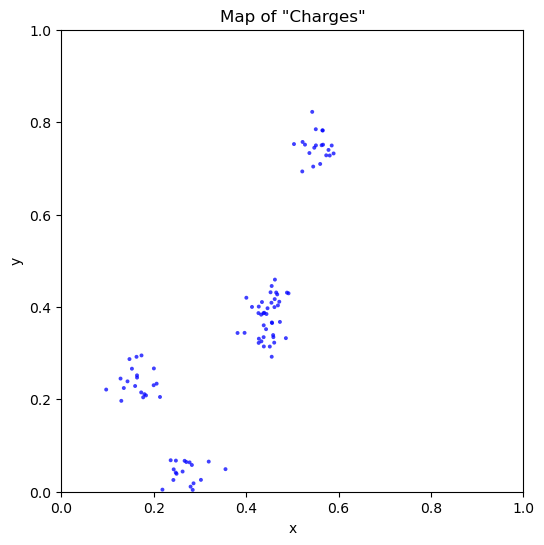

In [3]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")

ax.scatter(
    secondary_points[:, 0],
    secondary_points[:, 1],
    s=8,
    c="blue",
    alpha=0.75,
    edgecolors="none",
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title('Map of "Charges"')
ax.grid(False)
plt.show()


Do note that some charges may appear to overlap graphically, but the positions of each point are well defined and do not overlap. Also note that all points may not be visible due to a few potentially being placed over the square boundary - these points are still accounted for. The five clusters should be discernably visible, though some may be quite close to each other leading to some "spillover".

As our investigation focuses on the runtime of these algorithms with `N` and the computational aspect, for simplicity we choose to neglect prefactors, dimensions and units. For charges of the same sign, varying relative magnitudes will not affect the big O runtime complexity, and henceforth we choose for all particles to have the same magnitude for simplicity. If charges have opposite signs, then issues such as vanishing of lower order multipole expansion terms and catastrophic cancellation can become an issue - henceforth we review this issue later on, however for now we take the charges to be the same sign. We will find that FFM and BHM are at their greatest advantage over direct summing when all charges hold the same sign.

This means for computational purposes, the electrostatic potential energy of the system is equivalently to simply the sum of all the reciprocal distances over all the pair of charges, excluding self interactions and double counting. We seek different methods on the computation of this quantity.

We now define direct summation as the unordered sum of some kernel (function) over every pair of charges, excluding double counting and self interactions. The program assumes (as is standard in most physical scenarios) that the kernel is even in its argument - i.e. the potential felt by particle `i` due to that of `j` is equivalent (up to a charge / strength factor) to that felt by `j` due to `i`. This is clearly true in the electrostatic case and will apply to our other investigated methods.

In [4]:
def sum_pairwise_kernel(points, kernel):
    """Sum kernel(distance) over every unordered pair of distinct points."""
    points = np.asarray(points, dtype=float)
    total = 0.0

    for i in range(len(points) - 1):
        # Pair point i only with points after it, avoiding self interactions
        # and double counting the same unordered pair.
        vectors = points[i + 1 :] - points[i]
        distances = np.linalg.norm(vectors, axis=1)
        total += np.sum(kernel(distances))

    return total


We then define the Coulomb kernel ($ \frac{1}{|\mathbf{r}-\mathbf{r'}|} $), and sum over the above map as a test.

In [5]:
def inverse_distance_kernel(distance):
    """Return distance^-1 for a scalar or array of distances."""
    return distance ** -1


def inverse_distance_for_pair(point_a, point_b):
    """Return (length of the connecting vector between two dots)^-1."""
    connecting_vector = np.asarray(point_b) - np.asarray(point_a)
    return inverse_distance_kernel(np.linalg.norm(connecting_vector))


inverse_distance_pair_sum = sum_pairwise_kernel(secondary_points, inverse_distance_kernel)
print(f"The sum for the above configuration is {inverse_distance_pair_sum}")


The sum for the above configuration is 47970.23325603443


As an initial control test, we examine the runtime of direct summation from `n` running from 10 to 1000, in steps of 10. Note that `N = k*n` is the more relevant statistic, though for expected polynomial time, these two metrics should share equivalent big Os. As in the example map, we set `k = 5` and `sigma = 0.03`.

In [6]:
# Benchmark the pairwise kernel sum for repeated random generations.
# sigma and k are kept fixed at their preselected values above.
n_values = np.arange(10, 1001, 10)
num_random_generations = 10
kernel_to_benchmark = inverse_distance_kernel

benchmark_results = []
benchmark_maps_by_n = {}

for n_for_benchmark in n_values:
    generation_times = []
    generation_maps = []

    for _ in range(num_random_generations):
        # Generate a fresh random map: both the original points and the blue dots.
        benchmark_original_points = rng.uniform(0.0, 1.0, size=(k, 2))
        benchmark_offsets = rng.normal(
            loc=0.0,
            scale=sigma,
            size=(k, n_for_benchmark, 2),
        )
        benchmark_blue_points = (
            benchmark_original_points[:, np.newaxis, :] + benchmark_offsets
        ).reshape(k * n_for_benchmark, 2)

        # Time only the distance computation, kernel evaluation, and summing.
        start_time = perf_counter()
        pairwise_sum = sum_pairwise_kernel(benchmark_blue_points, kernel_to_benchmark)
        elapsed_time = perf_counter() - start_time

        generation_times.append(elapsed_time)
        generation_maps.append(benchmark_blue_points)

    benchmark_maps_by_n[int(n_for_benchmark)] = generation_maps

    benchmark_results.append(
        {
            "n": int(n_for_benchmark),
            "N": int(k * n_for_benchmark),
            "num_blue_points": int(k * n_for_benchmark),
            "average_time_seconds": float(np.mean(generation_times)),
            "all_times_seconds": generation_times,
            "last_pairwise_sum": float(pairwise_sum),
        }
    )


These results are then tabled (only `n = 10`, `n = 50` and every 50 thereafter) and then plotted (all the data). For each value of `n` we average over 10 iid map generations. (This may take a few minutes if rerunning).

   N = k*n   average time (s)
-----------------------------
        50           0.000771
       250           0.005068
       500           0.008224
       750           0.013191
      1000           0.023114
      1250           0.033557
      1500           0.050539
      1750           0.052523
      2000           0.068331
      2250           0.083639
      2500           0.099553
      2750           0.106346
      3000           0.132629
      3250           0.167550
      3500           0.181484
      3750           0.217882
      4000           0.230027
      4250           0.234625
      4500           0.289493
      4750           0.309815
      5000           0.330185


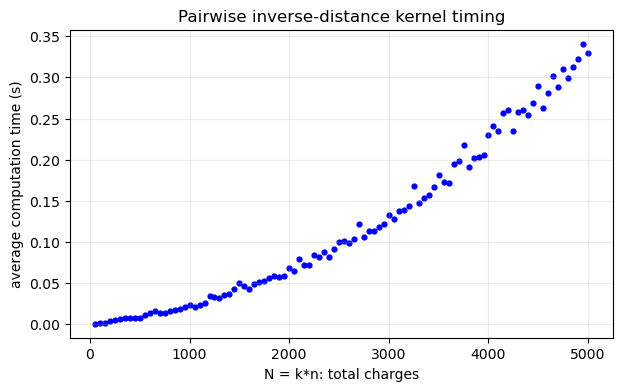

In [7]:
# Tabulate selected N = k*n values and plot N against the average computation time.
table_results = [
    result
    for result in benchmark_results
    if result["N"] == k * 10 or result["N"] % (k * 50) == 0
]

print(f"{'N = k*n':>10} {'average time (s)':>18}")
print("-" * 29)
for result in table_results:
    print(
        f"{result['N']:10d} "
        f"{result['average_time_seconds']:18.6f}"
    )

plot_N_values = [result["N"] for result in benchmark_results]
plot_average_times = [result["average_time_seconds"] for result in benchmark_results]

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(plot_N_values, plot_average_times, s=12, color="blue")
ax.set_xlabel("N = k*n: total charges")
ax.set_ylabel("average computation time (s)")
ax.set_title("Pairwise inverse-distance kernel timing")
ax.grid(True, alpha=0.25)
plt.show()


It is evident that the growth is faster than linear at a glance, but in order to gain a more precise growth measure, we plot this data on a log-log plot.

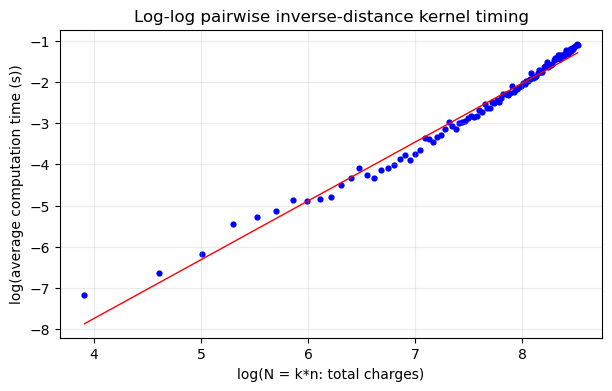

The gradient of the fitted line is 1.4267078071328059
The PMCC coefficient is 0.9917322406852155


In [8]:
# Plot log(time) against log(N) and fit a linear regression.
log_N_values = np.log(plot_N_values)
log_average_times = np.log(plot_average_times)

log_time_regression = scipy.stats.linregress(log_N_values, log_average_times)
line_of_best_fit = log_time_regression.intercept + log_time_regression.slope * log_N_values

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(log_N_values, log_average_times, s=12, color="blue")
ax.plot(log_N_values, line_of_best_fit, color="red", linewidth=1)
ax.set_xlabel("log(N = k*n: total charges)")
ax.set_ylabel("log(average computation time (s))")
ax.set_title("Log-log pairwise inverse-distance kernel timing")
ax.grid(True, alpha=0.25)
plt.show()

print(f"The gradient of the fitted line is {log_time_regression.slope}")
print(f"The PMCC coefficient is {log_time_regression.rvalue}")


If the algorithm is `O(N^2)`, then we would expect a log-log plot to have a derivative of 2. The derivative however appears well under that, typically in the 1.3 to 1.5 range (if you choose to rerun this notebook, you will get different values based on your generated maps). The plot shows the latter growth appears to have a higher gradient than the line of best illustrated on the plot. It is important to note that the true number of combinations involves a linear term, which we would expect to be dominated by the quadratic term in the asymptotic limit as N grows larger. For this reason, we redo the plot, excluding all data where `ln(n) < 5`.

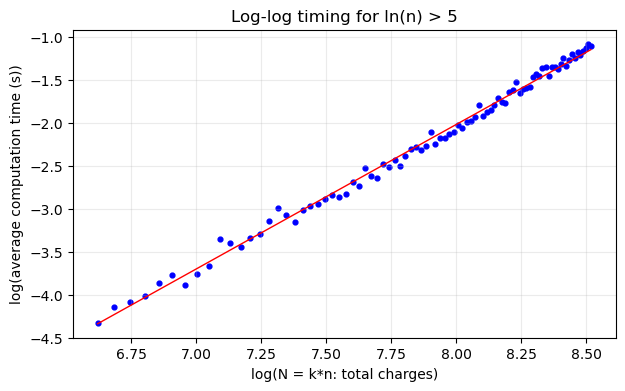

The gradient of the fitted line for ln(n) > 5 is 1.6835595487610298
The PMCC coefficient for ln(n) > 5 is 0.9971201963394065


In [9]:
# Repeat the log-log regression using only data points with ln(n) > 5.
log_n_values = np.log([result["n"] for result in benchmark_results])
large_log_n_mask = log_n_values > 5
large_log_N_values = log_N_values[large_log_n_mask]
large_log_average_times = log_average_times[large_log_n_mask]

large_log_time_regression = scipy.stats.linregress(
    large_log_N_values,
    large_log_average_times,
)
large_line_of_best_fit = (
    large_log_time_regression.intercept
    + large_log_time_regression.slope * large_log_N_values
)

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(large_log_N_values, large_log_average_times, s=12, color="blue")
ax.plot(large_log_N_values, large_line_of_best_fit, color="red", linewidth=1)
ax.set_xlabel("log(N = k*n: total charges)")
ax.set_ylabel("log(average computation time (s))")
ax.set_title("Log-log timing for ln(n) > 5")
ax.grid(True, alpha=0.25)
plt.show()

print(f"The gradient of the fitted line for ln(n) > 5 is {large_log_time_regression.slope}")
print(f"The PMCC coefficient for ln(n) > 5 is {large_log_time_regression.rvalue}")


The derivative has improved to the 1.6 to 1.7 range, which is an improvement but is is still a fair bit behind 2. The PMCC of 0.995+ indicates that a power law is a good approximation at least in this region of `ln(N)`, which is of course is contracted by the logarithm.

Further testing found that at `n = 10000`, derivatives improved (to expectation) to the 1.8 to 1.85 region. These trials have not been included here due to overly long runtime of these programs on this machine. This suggests at both the foregoing linear term as a factor, as well as some of the hidden efficiency of the direct summation method and certain NumPy functions used (we will reference these in more detail later).

We now define the Barnes-Hut algorithm and respective sum process [add explanation here].

We introduce the parameter `theta` which will prove pivotal to both other methods. Both the Barnes-Hut and Fast Multipole Method-style calculations use an opening parameter of the form `theta = s / d`, where `s` is a characteristic size of a cluster of charges and `d` is a characteristic separation between different original cluster centres. Ultimately these calculations are approximations. The approximation is more aggressive when `theta` is larger, because more groups are considered sufficiently far away to replace by an aggregate or multipole expansion.

For the cluster size, each coordinate is displaced from its original point by a normal random variable with standard deviation `sigma`. By the 68-95-99.7 rule, almost all normally distributed charge positions lie within about `3*sigma` of the "origin point". We therefore use `s ≈ 3*sigma` as a characteristic cluster scale.

For the separation `d`, treat the `k` original points in the unit square as a two-dimensional Poisson process with intensity `lambda = k`. This is a standard approximation for finding the distance between two "nearest neighbours" in a uniform distribution. For a 2D Poisson process, the nearest-neighbour distance has density `f(r) = 2*pi*lambda*r*exp(-pi*lambda*r^2)`, whose mean is `E[R] = 1/(2*sqrt(lambda))`. With `lambda = k`, this gives the characteristic spacing `d ≈ 1/(2*sqrt(k))`.

Combining these estimates gives

`theta = s/d ≈ (3*sigma)/(1/(2*sqrt(k))) = 6*sigma*sqrt(k)`.

This is only a heuristic scale choice: boundary effects, clustered randomness, and the desired accuracy can all justify changing `theta`, but it gives a simple way to tie the opening criterion to the generated point distribution. For the opening calculations, we will keep to this form an vary k and sigma approporiately. This is so to preserve the cluster effect of the charges. Later we will examine what happens for large `sigma` where the charges approach a uniform distribution.


In [10]:
# Barnes-Hut setup, part 1: build a quadtree representation of the point map.
# Each node stores the points in one square region, their count, and their center of mass.
# Nodes recursively split into four smaller squares until they contain at most leaf_size
# points, or until all their points lie at the same coordinates.
class QuadTreeNode:
    """A square quadtree node for Barnes-Hut style pairwise kernel sums."""

    def __init__(self, points, indices, center, half_width, leaf_size=8):
        # Store references to the full point array and the subset belonging to this node.
        self.points = points
        self.indices = np.asarray(indices, dtype=int)
        self.center = np.asarray(center, dtype=float)
        self.half_width = float(half_width)
        self.leaf_size = int(leaf_size)
        self.count = len(self.indices)
        self.children = []

        if self.count == 0:
            self.center_of_mass = self.center
            return

        # The center of mass is the single representative position used for far-away groups.
        self.center_of_mass = np.mean(self.points[self.indices], axis=0)

        # Split only when there are enough points and some non-zero spatial spread.
        point_spread = np.ptp(self.points[self.indices], axis=0)
        if self.count > self.leaf_size and np.any(point_spread > 0):
            self._subdivide()

    @property
    def is_leaf(self):
        return len(self.children) == 0

    def _subdivide(self):
        # Create four child squares: lower-left, lower-right, upper-left, and upper-right.
        child_half_width = self.half_width / 2
        offsets = np.array([
            [-child_half_width, -child_half_width],
            [child_half_width, -child_half_width],
            [-child_half_width, child_half_width],
            [child_half_width, child_half_width],
        ])

        # Assign each point in this node to exactly one child quadrant.
        local_points = self.points[self.indices]
        right = local_points[:, 0] > self.center[0]
        upper = local_points[:, 1] > self.center[1]
        quadrant_masks = [
            (~right) & (~upper),
            right & (~upper),
            (~right) & upper,
            right & upper,
        ]

        for offset, in_child in zip(offsets, quadrant_masks):
            child_indices = self.indices[in_child]

            if len(child_indices) > 0:
                self.children.append(
                    QuadTreeNode(
                        self.points,
                        child_indices,
                        self.center + offset,
                        child_half_width,
                        leaf_size=self.leaf_size,
                    )
                )


def build_quadtree(points, leaf_size=8):
    """Build a square quadtree that contains every point in the map."""
    points = np.asarray(points, dtype=float)
    # Build the root square around the whole point cloud.
    lower = np.min(points, axis=0)
    upper = np.max(points, axis=0)
    center = (lower + upper) / 2
    half_width = max(np.max(upper - lower) / 2, np.finfo(float).eps)
    # Pad very slightly so points on the boundary are retained robustly.
    half_width *= 1 + 1e-12
    return QuadTreeNode(points, np.arange(len(points)), center, half_width, leaf_size)


In [12]:
# Barnes-Hut setup, part 2: use the quadtree to approximate the pairwise kernel sum.
# For each target point, nearby leaf nodes are evaluated exactly, while sufficiently
# far-away nodes are collapsed into one center-of-mass contribution controlled by theta.
def barnes_hut_pairwise_kernel_sum(points, kernel, theta, leaf_size=8):
    """Approximate the unordered pairwise kernel sum using Barnes-Hut grouping.

    The kernel must accept a distance, or an array of distances, and return
    the corresponding interaction value(s). Distant groups are approximated
    by replacing all points in the group with their center of mass.
    """
    points = np.asarray(points, dtype=float)
    tree = build_quadtree(points, leaf_size=leaf_size)

    def contribution_from_node(point_index, node):
        if node.count == 0:
            return 0.0

        target_point = points[point_index]
        contains_target = point_index in node.indices
        distance_to_node = np.linalg.norm(node.center_of_mass - target_point)
        node_width = 2 * node.half_width

        if node.is_leaf:
            # Leaf nodes are small enough to evaluate exactly point by point.
            other_indices = node.indices[node.indices != point_index]
            if len(other_indices) == 0:
                return 0.0
            distances = np.linalg.norm(points[other_indices] - target_point, axis=1)
            return np.sum(kernel(distances))

        # Barnes-Hut opening criterion: if the node is far enough away, approximate
        # all points in the node by node.count copies at the node center of mass.
        if (not contains_target) and distance_to_node > 0 and node_width / distance_to_node < theta:
            return node.count * kernel(distance_to_node)

        # Otherwise, recurse into the children to get a more local approximation.
        return sum(contribution_from_node(point_index, child) for child in node.children)

    # Summing point-to-tree interactions counts each unordered pair twice.
    return 0.5 * sum(contribution_from_node(i, tree) for i in range(len(points)))


# Test the Barnes-Hut approximation on the current map with the inverse-distance kernel.
theta = 6 * sigma * k ** (1 / 2)

barnes_hut_inverse_distance_pair_sum = barnes_hut_pairwise_kernel_sum(
    secondary_points,
    inverse_distance_kernel,
    theta=theta,
    leaf_size=8,
)
print(f"The Barnes-Hut approximate sum for the initial example configuration is {barnes_hut_inverse_distance_pair_sum}")


The Barnes-Hut approximate sum for the initial example configuration is 47960.710642501224


We have recalculated the sum for the initial example. As Barnes-Hut is ultimately an approximation method, it should not be expected to perfectly match the "true" value provided by direct summation. Nevertheless we have accuracy to three significant figures (479...), showing merit for more rigorous trials.

We now do the same for Fast Multipole as we did for BHM. [Add explanation here]. We have selected accuracy up to the octupole moment.

Unfortunately FMM is more sensitive to the kernel chosen, so an individual program for the Couloumb Kernel is created. Any more may be created in due course.

In [15]:
# Fast Multipole Method setup for the inverse-distance kernel.
# This implementation supports monopole (0), dipole (1), quadrupole (2), and octupole (3) terms for 1/r interactions.
def inverse_distance_multipole_contribution(target_point, node, max_order=3):
    """Approximate one target point's interaction with one far-away node.

    The expansion is specific to the inverse-distance kernel 1/r. It expands
    source points around the node center of mass and evaluates the multipole
    contribution at target_point.
    """
    max_order = int(max_order)
    if max_order < 0 or max_order > 3:
        raise ValueError("max_order must be 0, 1, 2, or 3 for this implementation.")

    source_points = node.points[node.indices]
    expansion_center = node.center_of_mass
    displacement_to_target = target_point - expansion_center
    distance = np.linalg.norm(displacement_to_target)

    if distance == 0:
        return 0.0

    # Monopole term: collapse the node to node.count unit sources at its center of mass.
    contribution = node.count / distance

    if max_order >= 1:
        # Dipole correction. This is usually near zero because the expansion center is
        # the center of mass, but it is included for completeness and numerical drift.
        source_displacements = source_points - expansion_center
        first_moment = np.sum(source_displacements, axis=0)
        contribution += np.dot(first_moment, displacement_to_target) / distance**3

    if max_order >= 2:
        # Quadrupole correction from the second moment of the source displacements.
        second_moment = source_displacements.T @ source_displacements
        hessian = (
            3 * np.outer(displacement_to_target, displacement_to_target)
            - distance**2 * np.eye(2)
        ) / distance**5
        contribution += 0.5 * np.sum(second_moment * hessian)

    if max_order >= 3:
        # Octupole correction from the third moment of the source displacements.
        third_moment = np.einsum(
            "ni,nj,nk->ijk",
            source_displacements,
            source_displacements,
            source_displacements,
        )
        third_derivative = np.zeros((2, 2, 2))
        identity = np.eye(2)
        for i in range(2):
            for j in range(2):
                for m in range(2):
                    third_derivative[i, j, m] = (
                        3
                        * (
                            identity[i, j] * displacement_to_target[m]
                            + identity[i, m] * displacement_to_target[j]
                            + identity[j, m] * displacement_to_target[i]
                        )
                        / distance**5
                        - 15
                        * displacement_to_target[i]
                        * displacement_to_target[j]
                        * displacement_to_target[m]
                        / distance**7
                    )
        contribution -= np.sum(third_moment * third_derivative) / 6

    return contribution


In [16]:
# Test the inverse-distance Fast Multipole Method approximation on the current map.
def fast_multipole_inverse_distance_sum(points, theta, max_order=3, leaf_size=8):
    """Approximate the unordered inverse-distance pair sum with FMM-style moments.

    Nearby leaf nodes are evaluated exactly. Well-separated nodes are approximated
    using a truncated multipole expansion through max_order. This keeps the same
    pair-sum target as the exact calculation, then halves the point-to-tree total
    because each unordered pair is encountered from both endpoints.
    """
    points = np.asarray(points, dtype=float)
    tree = build_quadtree(points, leaf_size=leaf_size)

    def contribution_from_node(point_index, node):
        target_point = points[point_index]
        contains_target = point_index in node.indices
        distance_to_node = np.linalg.norm(node.center_of_mass - target_point)
        node_width = 2 * node.half_width

        if node.is_leaf:
            # Direct calculation for local interactions avoids singular self terms.
            other_indices = node.indices[node.indices != point_index]
            if len(other_indices) == 0:
                return 0.0
            distances = np.linalg.norm(points[other_indices] - target_point, axis=1)
            return np.sum(distances ** -1)

        # Multipole acceptance criterion: sufficiently distant nodes use the moment expansion.
        if (not contains_target) and distance_to_node > 0 and node_width / distance_to_node < theta:
            return inverse_distance_multipole_contribution(
                target_point,
                node,
                max_order=max_order,
            )

        # Otherwise descend to the children for a more detailed local calculation.
        return sum(contribution_from_node(point_index, child) for child in node.children)

    return 0.5 * sum(contribution_from_node(i, tree) for i in range(len(points)))


theta = 6 * sigma * k ** (1 / 2)
max_order = 3

fast_multipole_inverse_distance_pair_sum = fast_multipole_inverse_distance_sum(
    secondary_points,
    theta=theta,
    max_order=max_order,
    leaf_size=8,
)
print(
    "The Fast Multipole approximate sum for the above configuration is "
    f"{fast_multipole_inverse_distance_pair_sum}"
)


The Fast Multipole approximate sum for the above configuration is 47970.11067877352


This now matches to five significant figures (47970. ...), aslo worthy of more quantitative examination.

We now run over the range of `n = 10` to `n = 100` in 10s, and otherwise apply a similar process to before in terms of generating 10 random maps and averaging the time over: this means the testing range has been significantly shortened and we will explain why shortly. We will also list the values obtained in the simulations through all methods, and evaluate the average fractional error (against the "true" value obtained through direct summation) to verify validity of the results generated in any timeframe.

In [17]:
# Benchmark direct sum, BHM, and FMM on the same newly generated maps.
# For each n, generate 10 maps and run all three algorithms on each map.
comparison_n_values = np.arange(10, 101, 10)
comparison_num_random_generations = 10
theta = 6 * sigma * k ** (1 / 2)
max_order = 3

exact_bhm_fmm_benchmark_results = []

for n_for_benchmark in comparison_n_values:
    direct_generation_times = []
    bhm_generation_times = []
    fmm_generation_times = []
    direct_pairwise_sums = []
    bhm_pairwise_sums = []
    fmm_pairwise_sums = []

    for _ in range(comparison_num_random_generations):
        # Generate one new map, then use this exact same map for all three algorithms.
        comparison_original_points = rng.uniform(0.0, 1.0, size=(k, 2))
        comparison_offsets = rng.normal(
            loc=0.0,
            scale=sigma,
            size=(k, n_for_benchmark, 2),
        )
        comparison_blue_points = (
            comparison_original_points[:, np.newaxis, :] + comparison_offsets
        ).reshape(k * n_for_benchmark, 2)

        # Time the exact direct pairwise sum on this map.
        start_time = perf_counter()
        direct_pairwise_sum = sum_pairwise_kernel(
            comparison_blue_points,
            inverse_distance_kernel,
        )
        direct_elapsed_time = perf_counter() - start_time
        direct_generation_times.append(direct_elapsed_time)
        direct_pairwise_sums.append(direct_pairwise_sum)

        # Time the Barnes-Hut approximation on the same map.
        start_time = perf_counter()
        bhm_pairwise_sum = barnes_hut_pairwise_kernel_sum(
            comparison_blue_points,
            inverse_distance_kernel,
            theta=theta,
            leaf_size=8,
        )
        bhm_elapsed_time = perf_counter() - start_time
        bhm_generation_times.append(bhm_elapsed_time)
        bhm_pairwise_sums.append(bhm_pairwise_sum)

        # Time the FMM-style approximation on the same map.
        start_time = perf_counter()
        fmm_pairwise_sum = fast_multipole_inverse_distance_sum(
            comparison_blue_points,
            theta=theta,
            max_order=max_order,
            leaf_size=8,
        )
        fmm_elapsed_time = perf_counter() - start_time
        fmm_generation_times.append(fmm_elapsed_time)
        fmm_pairwise_sums.append(fmm_pairwise_sum)

    exact_bhm_fmm_benchmark_results.append(
        {
            "n": int(n_for_benchmark),
            "N": int(k * n_for_benchmark),
            "direct_average_time_seconds": float(np.mean(direct_generation_times)),
            "direct_all_times_seconds": direct_generation_times,
            "direct_all_pairwise_sums": [float(value) for value in direct_pairwise_sums],
            "direct_last_pairwise_sum": float(direct_pairwise_sum),
            "bhm_average_time_seconds": float(np.mean(bhm_generation_times)),
            "bhm_all_times_seconds": bhm_generation_times,
            "bhm_all_pairwise_sums": [float(value) for value in bhm_pairwise_sums],
            "bhm_last_pairwise_sum": float(bhm_pairwise_sum),
            "fmm_average_time_seconds": float(np.mean(fmm_generation_times)),
            "fmm_all_times_seconds": fmm_generation_times,
            "fmm_all_pairwise_sums": [float(value) for value in fmm_pairwise_sums],
            "fmm_last_pairwise_sum": float(fmm_pairwise_sum),
        }
    )


Largest n = 100; N = 500
trial         direct sum            BHM sum    BHM frac. error            FMM sum    FMM frac. error
-----------------------------------------------------------------------------------------------------
    1     1035388.201111     1035033.618598       3.424634e-04     1035384.994203       3.097301e-06
    2     1041444.334966     1040898.047203       5.245482e-04     1041436.420059       7.599933e-06
    3      986059.634100      985413.933002       6.548297e-04      986051.648981       8.098009e-06
    4      948260.904683      947914.726585       3.650663e-04      948257.961528       3.103739e-06
    5      931564.227875      931300.485514       2.831177e-04      931562.322066       2.045816e-06
    6      990768.028600      990448.925057       3.220769e-04      990765.951049       2.096910e-06
    7     1010927.277113     1010417.665673       5.041030e-04     1010923.376542       3.858409e-06
    8     1165399.628278     1164444.880261       8.192452e-04   

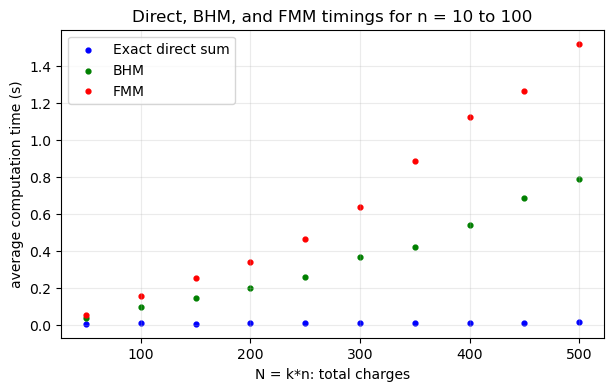

In [18]:
# Detailed sums and fractional errors for the largest n value in this experiment.
comparison_largest_n_result = max(exact_bhm_fmm_benchmark_results, key=lambda result: result["n"])
comparison_direct_sums = np.asarray(comparison_largest_n_result["direct_all_pairwise_sums"])
comparison_bhm_sums = np.asarray(comparison_largest_n_result["bhm_all_pairwise_sums"])
comparison_fmm_sums = np.asarray(comparison_largest_n_result["fmm_all_pairwise_sums"])
comparison_bhm_fractional_errors = np.abs(comparison_bhm_sums - comparison_direct_sums) / np.abs(comparison_direct_sums)
comparison_fmm_fractional_errors = np.abs(comparison_fmm_sums - comparison_direct_sums) / np.abs(comparison_direct_sums)

print(f"Largest n = {comparison_largest_n_result['n']}; N = {comparison_largest_n_result['N']}")
print(
    f"{'trial':>5} "
    f"{'direct sum':>18} "
    f"{'BHM sum':>18} "
    f"{'BHM frac. error':>18} "
    f"{'FMM sum':>18} "
    f"{'FMM frac. error':>18}"
)
print("-" * 101)
for trial_index, (direct_sum, bhm_sum, bhm_error, fmm_sum, fmm_error) in enumerate(
    zip(
        comparison_direct_sums,
        comparison_bhm_sums,
        comparison_bhm_fractional_errors,
        comparison_fmm_sums,
        comparison_fmm_fractional_errors,
    ),
    start=1,
):
    print(
        f"{trial_index:5d} "
        f"{direct_sum:18.6f} "
        f"{bhm_sum:18.6f} "
        f"{bhm_error:18.6e} "
        f"{fmm_sum:18.6f} "
        f"{fmm_error:18.6e}"
    )

print("Averages over these largest-n trials:")
print(f"Average direct sum: {np.mean(comparison_direct_sums)}")
print(f"Average BHM sum: {np.mean(comparison_bhm_sums)}")
print(f"Average BHM fractional error: {np.mean(comparison_bhm_fractional_errors)}")
print(f"Average FMM sum: {np.mean(comparison_fmm_sums)}")
print(f"Average FMM fractional error: {np.mean(comparison_fmm_fractional_errors)}")
print()

# Tabulate and plot direct, BHM, and FMM timing results from the shared-map benchmark.
print(
    f"{'N = k*n':>10} "
    f"{'Direct average (s)':>20} "
    f"{'BHM average (s)':>18} "
    f"{'FMM average (s)':>18}"
)
print("-" * 72)
for result in exact_bhm_fmm_benchmark_results:
    print(
        f"{result['N']:10d} "
        f"{result['direct_average_time_seconds']:20.6f} "
        f"{result['bhm_average_time_seconds']:18.6f} "
        f"{result['fmm_average_time_seconds']:18.6f}"
    )

plot_N_values = [result["N"] for result in exact_bhm_fmm_benchmark_results]
plot_direct_average_times = [result["direct_average_time_seconds"] for result in exact_bhm_fmm_benchmark_results]
plot_bhm_average_times = [result["bhm_average_time_seconds"] for result in exact_bhm_fmm_benchmark_results]
plot_fmm_average_times = [result["fmm_average_time_seconds"] for result in exact_bhm_fmm_benchmark_results]

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(plot_N_values, plot_direct_average_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(plot_N_values, plot_bhm_average_times, s=12, color="green", label="BHM")
ax.scatter(plot_N_values, plot_fmm_average_times, s=12, color="red", label="FMM")
ax.set_xlabel("N = k*n: total charges")
ax.set_ylabel("average computation time (s)")
ax.set_title("Direct, BHM, and FMM timings for n = 10 to 100")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


Fractional error for this `theta` value sits at around ${10}^{-4}$ in the FHM case and ${10}^{-6}$ in the FMM case, so at this stricy a tolerance parameter, we should find the validity of the results through the alternative algorithms more than satisfactory.

However immediately we see the formation of a surprising trend: BHM and FMM at low range appear to be siginificantly inferior to standard summation. We examine a log-log plot as before to gain more information on growth ratesm bearing in mind that `N` is 10 times less at its maximum than our previous simulation, so sub-quadratic growth from the direct sum should be expected.

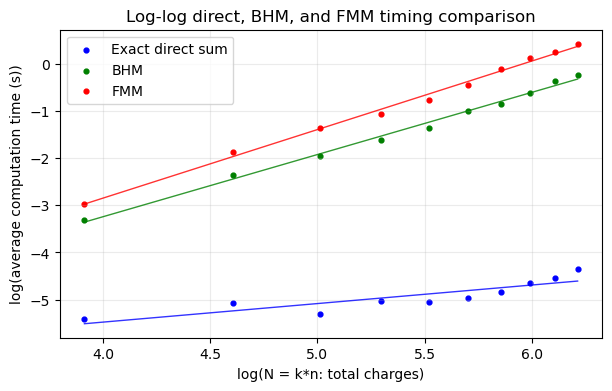

Direct gradient: 0.3922157973381328
Direct PMCC: 0.8739352512722921
BHM gradient: 1.3150585296418487
BHM PMCC: 0.9969149300307901
FMM gradient: 1.44936807279794
FMM PMCC: 0.9973753522845707


In [19]:
# Log-log plot of direct, BHM, and FMM timings with separate lines of best fit.
log_comparison_N_values = np.log([result["N"] for result in exact_bhm_fmm_benchmark_results])
log_direct_times = np.log([result["direct_average_time_seconds"] for result in exact_bhm_fmm_benchmark_results])
log_bhm_times = np.log([result["bhm_average_time_seconds"] for result in exact_bhm_fmm_benchmark_results])
log_fmm_times = np.log([result["fmm_average_time_seconds"] for result in exact_bhm_fmm_benchmark_results])

direct_log_regression = scipy.stats.linregress(log_comparison_N_values, log_direct_times)
bhm_log_regression = scipy.stats.linregress(log_comparison_N_values, log_bhm_times)
fmm_log_regression = scipy.stats.linregress(log_comparison_N_values, log_fmm_times)

direct_line_of_best_fit = direct_log_regression.intercept + direct_log_regression.slope * log_comparison_N_values
bhm_line_of_best_fit = bhm_log_regression.intercept + bhm_log_regression.slope * log_comparison_N_values
fmm_line_of_best_fit = fmm_log_regression.intercept + fmm_log_regression.slope * log_comparison_N_values

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(log_comparison_N_values, log_direct_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(log_comparison_N_values, log_bhm_times, s=12, color="green", label="BHM")
ax.scatter(log_comparison_N_values, log_fmm_times, s=12, color="red", label="FMM")
ax.plot(log_comparison_N_values, direct_line_of_best_fit, color="blue", linewidth=1, alpha=0.8)
ax.plot(log_comparison_N_values, bhm_line_of_best_fit, color="green", linewidth=1, alpha=0.8)
ax.plot(log_comparison_N_values, fmm_line_of_best_fit, color="red", linewidth=1, alpha=0.8)
ax.set_xlabel("log(N = k*n: total charges)")
ax.set_ylabel("log(average computation time (s))")
ax.set_title("Log-log direct, BHM, and FMM timing comparison")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

print(f"Direct gradient: {direct_log_regression.slope}")
print(f"Direct PMCC: {direct_log_regression.rvalue}")
print(f"BHM gradient: {bhm_log_regression.slope}")
print(f"BHM PMCC: {bhm_log_regression.rvalue}")
print(f"FMM gradient: {fmm_log_regression.slope}")
print(f"FMM PMCC: {fmm_log_regression.rvalue}")


Both BHM and FMM post sub-quadratic growth rates, yet remain vastly inferior to direct summing. It should be pointed out though that at this scale, direct summing is even sub-linear, so the advertized `O(N ln(N))` of BHM or even the very ambitious `O(N)` of FMM would not beat direct at this scale. 

At this stage it should be made clear that whilst simulations ranging to the previous `n` limits (circa `n = 1000`), once again simulations times prohibited, with simulations at this level of accuracy (`theta` value) for extended `n` limits requiring over half an hour per simulation. We will observe the effect of more leinient `theta` values shortly. The option to alter the maximum order of FMM expansion also exists but will be kept the same throughout as to maximize the number of controls.

Although direct summation has `O(N^2)` scaling, it can still be competitive or faster for smaller point sets. In these experiments, the direct method uses NumPy vector operations to subtract many points, compute many distances, apply the kernel, and sum values in optimized compiled code. That means much of the pairwise arithmetic is performed in tight low-level loops rather than in Python.

By contrast, the Barnes-Hut and FMM-style routines have overhead from building and traversing quadtrees, making recursive Python function calls, checking opening criteria, and managing many small arrays or node objects. At low `N`, these setup and traversal costs can dominate the savings from approximating far-field interactions. The asymptotic advantages of BHM/FMM are therefore expected to appear only once `N` is large enough that avoiding many pairwise interactions outweighs the Python/tree overhead.

Already a theme is emerging with all algorithms - particularly with BHM and FMM - that whilst theoretical asymptotic optimum runtimes exist, reaching them in small practical scale operations is infeasible and unlikely to beat out direct summation.


We perfom a series of experiments which alter parameters which have a concequence on the `theta` value, to evaluate its role in prohibiting swift calculations. The first way we attempt to do this is raise `sigma` such that `theta = 0.8` (keeping `k = 5`). We pick `theta = 0.8` as an upper bound for acceptable `theta` in order to prevent fractional error on the order of single digit percent. This leads to a `sigma` value of about 0.0596 - i.e. about a doubling.

In [21]:
# Repeat the direct, BHM, and FMM benchmark with theta fixed at 0.8.
# Keep k = 5 and choose sigma so that theta = 6*sigma*k^(1/2) = 0.8.
theta_08_k = 5
theta_08 = 0.8
theta_08_sigma = theta_08 / (6 * theta_08_k ** (1 / 2))
theta_08_n_values = np.arange(10, 101, 10)
theta_08_num_random_generations = 10
max_order = 3

theta_08_benchmark_results = []

for n_for_benchmark in theta_08_n_values:
    direct_generation_times = []
    bhm_generation_times = []
    fmm_generation_times = []
    direct_pairwise_sums = []
    bhm_pairwise_sums = []
    fmm_pairwise_sums = []

    for _ in range(theta_08_num_random_generations):
        # Generate one new map with the theta=0.8 sigma, then use it for all algorithms.
        theta_08_original_points = rng.uniform(0.0, 1.0, size=(theta_08_k, 2))
        theta_08_offsets = rng.normal(
            loc=0.0,
            scale=theta_08_sigma,
            size=(theta_08_k, n_for_benchmark, 2),
        )
        theta_08_blue_points = (
            theta_08_original_points[:, np.newaxis, :] + theta_08_offsets
        ).reshape(theta_08_k * n_for_benchmark, 2)

        # Time the exact direct pairwise sum on this map.
        start_time = perf_counter()
        direct_pairwise_sum = sum_pairwise_kernel(
            theta_08_blue_points,
            inverse_distance_kernel,
        )
        direct_elapsed_time = perf_counter() - start_time
        direct_generation_times.append(direct_elapsed_time)
        direct_pairwise_sums.append(direct_pairwise_sum)

        # Time the Barnes-Hut approximation on the same map.
        start_time = perf_counter()
        bhm_pairwise_sum = barnes_hut_pairwise_kernel_sum(
            theta_08_blue_points,
            inverse_distance_kernel,
            theta=theta_08,
            leaf_size=8,
        )
        bhm_elapsed_time = perf_counter() - start_time
        bhm_generation_times.append(bhm_elapsed_time)
        bhm_pairwise_sums.append(bhm_pairwise_sum)

        # Time the FMM-style approximation on the same map.
        start_time = perf_counter()
        fmm_pairwise_sum = fast_multipole_inverse_distance_sum(
            theta_08_blue_points,
            theta=theta_08,
            max_order=max_order,
            leaf_size=8,
        )
        fmm_elapsed_time = perf_counter() - start_time
        fmm_generation_times.append(fmm_elapsed_time)
        fmm_pairwise_sums.append(fmm_pairwise_sum)

    theta_08_benchmark_results.append(
        {
            "n": int(n_for_benchmark),
            "N": int(theta_08_k * n_for_benchmark),
            "sigma": float(theta_08_sigma),
            "theta": float(theta_08),
            "direct_average_time_seconds": float(np.mean(direct_generation_times)),
            "direct_all_times_seconds": direct_generation_times,
            "direct_all_pairwise_sums": [float(value) for value in direct_pairwise_sums],
            "direct_last_pairwise_sum": float(direct_pairwise_sum),
            "bhm_average_time_seconds": float(np.mean(bhm_generation_times)),
            "bhm_all_times_seconds": bhm_generation_times,
            "bhm_all_pairwise_sums": [float(value) for value in bhm_pairwise_sums],
            "bhm_last_pairwise_sum": float(bhm_pairwise_sum),
            "fmm_average_time_seconds": float(np.mean(fmm_generation_times)),
            "fmm_all_times_seconds": fmm_generation_times,
            "fmm_all_pairwise_sums": [float(value) for value in fmm_pairwise_sums],
            "fmm_last_pairwise_sum": float(fmm_pairwise_sum),
        }
    )


Largest n = 100; N = 500
trial         direct sum            BHM sum    BHM frac. error            FMM sum    FMM frac. error
-----------------------------------------------------------------------------------------------------
    1      635150.723906      632400.992987       4.329257e-03      635014.312254       2.147705e-04
    2      829048.336783      824055.663639       6.022174e-03      828751.505098       3.580391e-04
    3      652642.010318      648835.071470       5.833120e-03      652436.421069       3.150107e-04
    4      580847.822290      578171.585013       4.607467e-03      580695.915960       2.615252e-04
    5      575373.486642      572783.947492       4.500623e-03      575261.855052       1.940159e-04
    6      623969.791824      620341.970533       5.814098e-03      623778.036552       3.073150e-04
    7      615823.453375      613098.907790       4.424232e-03      615694.752652       2.089896e-04
    8      674241.885084      670927.943754       4.915063e-03   

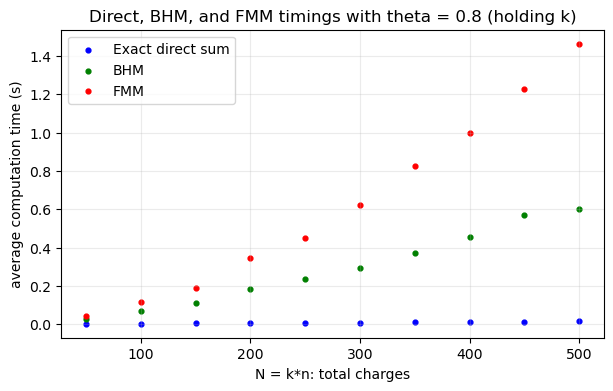

In [24]:
# Detailed sums and fractional errors for the largest n value in this experiment.
theta_08_largest_n_result = max(theta_08_benchmark_results, key=lambda result: result["n"])
theta_08_direct_sums = np.asarray(theta_08_largest_n_result["direct_all_pairwise_sums"])
theta_08_bhm_sums = np.asarray(theta_08_largest_n_result["bhm_all_pairwise_sums"])
theta_08_fmm_sums = np.asarray(theta_08_largest_n_result["fmm_all_pairwise_sums"])
theta_08_bhm_fractional_errors = np.abs(theta_08_bhm_sums - theta_08_direct_sums) / np.abs(theta_08_direct_sums)
theta_08_fmm_fractional_errors = np.abs(theta_08_fmm_sums - theta_08_direct_sums) / np.abs(theta_08_direct_sums)

print(f"Largest n = {theta_08_largest_n_result['n']}; N = {theta_08_largest_n_result['N']}")
print(
    f"{'trial':>5} "
    f"{'direct sum':>18} "
    f"{'BHM sum':>18} "
    f"{'BHM frac. error':>18} "
    f"{'FMM sum':>18} "
    f"{'FMM frac. error':>18}"
)
print("-" * 101)
for trial_index, (direct_sum, bhm_sum, bhm_error, fmm_sum, fmm_error) in enumerate(
    zip(
        theta_08_direct_sums,
        theta_08_bhm_sums,
        theta_08_bhm_fractional_errors,
        theta_08_fmm_sums,
        theta_08_fmm_fractional_errors,
    ),
    start=1,
):
    print(
        f"{trial_index:5d} "
        f"{direct_sum:18.6f} "
        f"{bhm_sum:18.6f} "
        f"{bhm_error:18.6e} "
        f"{fmm_sum:18.6f} "
        f"{fmm_error:18.6e}"
    )

print("Averages over these largest-n trials:")
print(f"Average direct sum: {np.mean(theta_08_direct_sums)}")
print(f"Average BHM sum: {np.mean(theta_08_bhm_sums)}")
print(f"Average BHM fractional error: {np.mean(theta_08_bhm_fractional_errors)}")
print(f"Average FMM sum: {np.mean(theta_08_fmm_sums)}")
print(f"Average FMM fractional error: {np.mean(theta_08_fmm_fractional_errors)}")
print()

# Tabulate and plot the theta=0.8 benchmark results.
print(f"theta = {theta_08}")
print(f"k = {theta_08_k}")
print(f"sigma = {theta_08_sigma}")
print(
    f"{'N = k*n':>10} "
    f"{'Direct average (s)':>20} "
    f"{'BHM average (s)':>18} "
    f"{'FMM average (s)':>18}"
)
print("-" * 72)
for result in theta_08_benchmark_results:
    print(
        f"{result['N']:10d} "
        f"{result['direct_average_time_seconds']:20.6f} "
        f"{result['bhm_average_time_seconds']:18.6f} "
        f"{result['fmm_average_time_seconds']:18.6f}"
    )

theta_08_plot_N_values = [result["N"] for result in theta_08_benchmark_results]
theta_08_direct_average_times = [result["direct_average_time_seconds"] for result in theta_08_benchmark_results]
theta_08_bhm_average_times = [result["bhm_average_time_seconds"] for result in theta_08_benchmark_results]
theta_08_fmm_average_times = [result["fmm_average_time_seconds"] for result in theta_08_benchmark_results]

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(theta_08_plot_N_values, theta_08_direct_average_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(theta_08_plot_N_values, theta_08_bhm_average_times, s=12, color="green", label="BHM")
ax.scatter(theta_08_plot_N_values, theta_08_fmm_average_times, s=12, color="red", label="FMM")
ax.set_xlabel("N = k*n: total charges")
ax.set_ylabel("average computation time (s)")
ax.set_title("Direct, BHM, and FMM timings with theta = 0.8 (holding k)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


Fractional errors have worsened to ${10}^{-3}$ and ${10}^{-4}$ for the BHM and FMM methods repsectively, but still at acceptable methods for most purposes. The growth rate of FMM appears to be affected minimally (still at 1.5s for `N = 500` but BHM has improved by $25%$ (0.6s at `N = 500`, as opposed to 0.8s) which can be verified against the previous plots.  

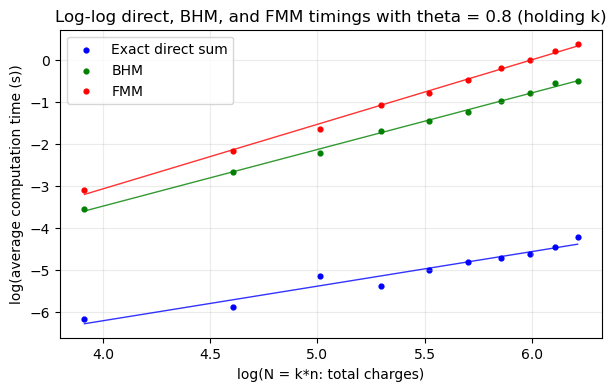

Direct gradient: 0.8210837617811538
Direct PMCC: 0.9713044807274223
BHM gradient: 1.3449591926003919
BHM PMCC: 0.9987470710305381
FMM gradient: 1.5325653395888608
FMM PMCC: 0.9982299019743084


In [25]:
# Log-log plot for the theta=0.8 benchmark with separate lines of best fit.
theta_08_log_N_values = np.log([result["N"] for result in theta_08_benchmark_results])
theta_08_log_direct_times = np.log([result["direct_average_time_seconds"] for result in theta_08_benchmark_results])
theta_08_log_bhm_times = np.log([result["bhm_average_time_seconds"] for result in theta_08_benchmark_results])
theta_08_log_fmm_times = np.log([result["fmm_average_time_seconds"] for result in theta_08_benchmark_results])

theta_08_direct_log_regression = scipy.stats.linregress(theta_08_log_N_values, theta_08_log_direct_times)
theta_08_bhm_log_regression = scipy.stats.linregress(theta_08_log_N_values, theta_08_log_bhm_times)
theta_08_fmm_log_regression = scipy.stats.linregress(theta_08_log_N_values, theta_08_log_fmm_times)

theta_08_direct_line_of_best_fit = theta_08_direct_log_regression.intercept + theta_08_direct_log_regression.slope * theta_08_log_N_values
theta_08_bhm_line_of_best_fit = theta_08_bhm_log_regression.intercept + theta_08_bhm_log_regression.slope * theta_08_log_N_values
theta_08_fmm_line_of_best_fit = theta_08_fmm_log_regression.intercept + theta_08_fmm_log_regression.slope * theta_08_log_N_values

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(theta_08_log_N_values, theta_08_log_direct_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(theta_08_log_N_values, theta_08_log_bhm_times, s=12, color="green", label="BHM")
ax.scatter(theta_08_log_N_values, theta_08_log_fmm_times, s=12, color="red", label="FMM")
ax.plot(theta_08_log_N_values, theta_08_direct_line_of_best_fit, color="blue", linewidth=1, alpha=0.8)
ax.plot(theta_08_log_N_values, theta_08_bhm_line_of_best_fit, color="green", linewidth=1, alpha=0.8)
ax.plot(theta_08_log_N_values, theta_08_fmm_line_of_best_fit, color="red", linewidth=1, alpha=0.8)
ax.set_xlabel("log(N = k*n: total charges)")
ax.set_ylabel("log(average computation time (s))")
ax.set_title("Log-log direct, BHM, and FMM timings with theta = 0.8 (holding k)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

print(f"Direct gradient: {theta_08_direct_log_regression.slope}")
print(f"Direct PMCC: {theta_08_direct_log_regression.rvalue}")
print(f"BHM gradient: {theta_08_bhm_log_regression.slope}")
print(f"BHM PMCC: {theta_08_bhm_log_regression.rvalue}")
print(f"FMM gradient: {theta_08_fmm_log_regression.slope}")
print(f"FMM PMCC: {theta_08_fmm_log_regression.rvalue}")


The local power relationship for BHM and FMM only increased slightly, but the power associated with direct summing more than doubled (0.39 to 0.82). Still however, direct summing remains much more efficient.

Below is an illustration of a possible map sample under these parameters. (Some dots may appear off the square with increased variance).

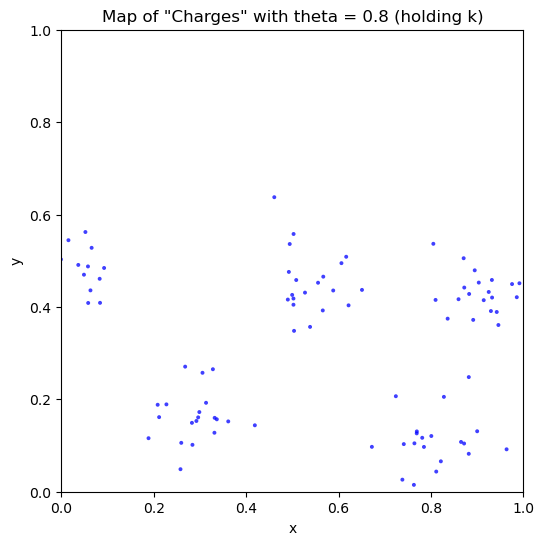

In [29]:
# Generate and plot a map using the sigma value from the theta=0.8 experiment.
theta_08_map_original_points = rng.uniform(0.0, 1.0, size=(theta_08_k, 2))
theta_08_map_offsets = rng.normal(
    loc=0.0,
    scale=theta_08_sigma,
    size=(theta_08_k, n, 2),
)
theta_08_map_points = (
    theta_08_map_original_points[:, np.newaxis, :] + theta_08_map_offsets
).reshape(theta_08_k * n, 2)

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")
ax.scatter(
    theta_08_map_points[:, 0],
    theta_08_map_points[:, 1],
    s=8,
    c="blue",
    alpha=0.75,
    edgecolors="none",
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title('Map of "Charges" with theta = 0.8 (holding k)')
ax.grid(False)
plt.show()


This time we take the opposite approach. We hold `sigma` at 0.03 and find the smallest integer `k` such that `theta > 0.8` (increasing `k` leads to increasing `theta`). This leads to `k = 20` and `theta = 0.80498`. To compensate for the increasing `k` leading to increasing `N`, the `n` is decreased by the same factor (4). 10, 30, 50 etc. are not divisible by 4 so only multiples of 20 (then divided by 4) are checked for `n`.

In [31]:
# Repeat the direct, BHM, and FMM benchmark with sigma reset to 0.03.
# Choose the lowest integer k such that theta = 6*sigma*k^(1/2) > 0.8.
sigma_003_k_threshold_sigma = 0.03
sigma_003_k_threshold_k = int(np.floor((0.8 / (6 * sigma_003_k_threshold_sigma)) ** 2) + 1)
sigma_003_k_threshold_theta = 6 * sigma_003_k_threshold_sigma * sigma_003_k_threshold_k ** (1 / 2)
# Reduced n range for divisibilty by 4 / compensating for k change to keep N constant
sigma_003_k_threshold_n_values = np.arange(5, 21, 5)
sigma_003_k_threshold_num_random_generations = 10
max_order = 3

sigma_003_k_threshold_benchmark_results = []

for n_for_benchmark in sigma_003_k_threshold_n_values:
    direct_generation_times = []
    bhm_generation_times = []
    fmm_generation_times = []
    direct_pairwise_sums = []
    bhm_pairwise_sums = []
    fmm_pairwise_sums = []

    for _ in range(sigma_003_k_threshold_num_random_generations):
        # Generate one new map with sigma=0.03 and the threshold k, then use it for all algorithms.
        sigma_003_k_threshold_original_points = rng.uniform(
            0.0,
            1.0,
            size=(sigma_003_k_threshold_k, 2),
        )
        sigma_003_k_threshold_offsets = rng.normal(
            loc=0.0,
            scale=sigma_003_k_threshold_sigma,
            size=(sigma_003_k_threshold_k, n_for_benchmark, 2),
        )
        sigma_003_k_threshold_blue_points = (
            sigma_003_k_threshold_original_points[:, np.newaxis, :]
            + sigma_003_k_threshold_offsets
        ).reshape(sigma_003_k_threshold_k * n_for_benchmark, 2)

        # Time the exact direct pairwise sum on this map.
        start_time = perf_counter()
        direct_pairwise_sum = sum_pairwise_kernel(
            sigma_003_k_threshold_blue_points,
            inverse_distance_kernel,
        )
        direct_elapsed_time = perf_counter() - start_time
        direct_generation_times.append(direct_elapsed_time)
        direct_pairwise_sums.append(direct_pairwise_sum)

        # Time the Barnes-Hut approximation on the same map.
        start_time = perf_counter()
        bhm_pairwise_sum = barnes_hut_pairwise_kernel_sum(
            sigma_003_k_threshold_blue_points,
            inverse_distance_kernel,
            theta=sigma_003_k_threshold_theta,
            leaf_size=8,
        )
        bhm_elapsed_time = perf_counter() - start_time
        bhm_generation_times.append(bhm_elapsed_time)
        bhm_pairwise_sums.append(bhm_pairwise_sum)

        # Time the FMM-style approximation on the same map.
        start_time = perf_counter()
        fmm_pairwise_sum = fast_multipole_inverse_distance_sum(
            sigma_003_k_threshold_blue_points,
            theta=sigma_003_k_threshold_theta,
            max_order=max_order,
            leaf_size=8,
        )
        fmm_elapsed_time = perf_counter() - start_time
        fmm_generation_times.append(fmm_elapsed_time)
        fmm_pairwise_sums.append(fmm_pairwise_sum)

    sigma_003_k_threshold_benchmark_results.append(
        {
            "n": int(n_for_benchmark),
            "N": int(sigma_003_k_threshold_k * n_for_benchmark),
            "sigma": float(sigma_003_k_threshold_sigma),
            "k": int(sigma_003_k_threshold_k),
            "theta": float(sigma_003_k_threshold_theta),
            "direct_average_time_seconds": float(np.mean(direct_generation_times)),
            "direct_all_times_seconds": direct_generation_times,
            "direct_all_pairwise_sums": [float(value) for value in direct_pairwise_sums],
            "direct_last_pairwise_sum": float(direct_pairwise_sum),
            "bhm_average_time_seconds": float(np.mean(bhm_generation_times)),
            "bhm_all_times_seconds": bhm_generation_times,
            "bhm_all_pairwise_sums": [float(value) for value in bhm_pairwise_sums],
            "bhm_last_pairwise_sum": float(bhm_pairwise_sum),
            "fmm_average_time_seconds": float(np.mean(fmm_generation_times)),
            "fmm_all_times_seconds": fmm_generation_times,
            "fmm_all_pairwise_sums": [float(value) for value in fmm_pairwise_sums],
            "fmm_last_pairwise_sum": float(fmm_pairwise_sum),
        }
    )


Largest n = 20; N = 400
trial         direct sum            BHM sum    BHM frac. error            FMM sum    FMM frac. error
-----------------------------------------------------------------------------------------------------
    1      337280.861652      335647.622500       4.842371e-03      337145.575313       4.011089e-04
    2      337069.768125      335535.852628       4.550736e-03      336978.887779       2.696188e-04
    3      347995.663082      346747.182345       3.587633e-03      347922.597937       2.099599e-04
    4      308087.527113      306821.821337       4.108267e-03      308020.337359       2.180866e-04
    5      296806.550020      295717.812236       3.668173e-03      296738.428313       2.295155e-04
    6      342333.457244      340280.410754       5.997213e-03      342209.837579       3.611089e-04
    7      326371.203549      325069.798253       3.987500e-03      326307.078582       1.964786e-04
    8      313914.523217      312433.946168       4.716497e-03    

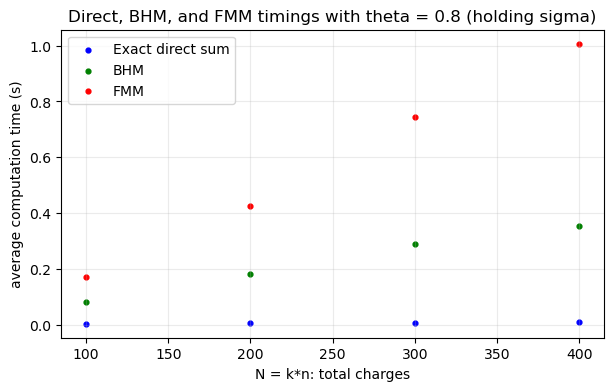

In [32]:
# Detailed sums and fractional errors for the largest n value in this experiment.
sigma_003_k_threshold_largest_n_result = max(sigma_003_k_threshold_benchmark_results, key=lambda result: result["n"])
sigma_003_k_threshold_direct_sums = np.asarray(sigma_003_k_threshold_largest_n_result["direct_all_pairwise_sums"])
sigma_003_k_threshold_bhm_sums = np.asarray(sigma_003_k_threshold_largest_n_result["bhm_all_pairwise_sums"])
sigma_003_k_threshold_fmm_sums = np.asarray(sigma_003_k_threshold_largest_n_result["fmm_all_pairwise_sums"])
sigma_003_k_threshold_bhm_fractional_errors = np.abs(sigma_003_k_threshold_bhm_sums - sigma_003_k_threshold_direct_sums) / np.abs(sigma_003_k_threshold_direct_sums)
sigma_003_k_threshold_fmm_fractional_errors = np.abs(sigma_003_k_threshold_fmm_sums - sigma_003_k_threshold_direct_sums) / np.abs(sigma_003_k_threshold_direct_sums)

print(f"Largest n = {sigma_003_k_threshold_largest_n_result['n']}; N = {sigma_003_k_threshold_largest_n_result['N']}")
print(
    f"{'trial':>5} "
    f"{'direct sum':>18} "
    f"{'BHM sum':>18} "
    f"{'BHM frac. error':>18} "
    f"{'FMM sum':>18} "
    f"{'FMM frac. error':>18}"
)
print("-" * 101)
for trial_index, (direct_sum, bhm_sum, bhm_error, fmm_sum, fmm_error) in enumerate(
    zip(
        sigma_003_k_threshold_direct_sums,
        sigma_003_k_threshold_bhm_sums,
        sigma_003_k_threshold_bhm_fractional_errors,
        sigma_003_k_threshold_fmm_sums,
        sigma_003_k_threshold_fmm_fractional_errors,
    ),
    start=1,
):
    print(
        f"{trial_index:5d} "
        f"{direct_sum:18.6f} "
        f"{bhm_sum:18.6f} "
        f"{bhm_error:18.6e} "
        f"{fmm_sum:18.6f} "
        f"{fmm_error:18.6e}"
    )

print("Averages over these largest-n trials:")
print(f"Average direct sum: {np.mean(sigma_003_k_threshold_direct_sums)}")
print(f"Average BHM sum: {np.mean(sigma_003_k_threshold_bhm_sums)}")
print(f"Average BHM fractional error: {np.mean(sigma_003_k_threshold_bhm_fractional_errors)}")
print(f"Average FMM sum: {np.mean(sigma_003_k_threshold_fmm_sums)}")
print(f"Average FMM fractional error: {np.mean(sigma_003_k_threshold_fmm_fractional_errors)}")
print()

# Tabulate and plot the sigma=0.03, threshold-k benchmark results.
print(f"sigma = {sigma_003_k_threshold_sigma}")
print(f"k = {sigma_003_k_threshold_k}")
print(f"theta = {sigma_003_k_threshold_theta}")
print(
    f"{'N = k*n':>10} "
    f"{'Direct average (s)':>20} "
    f"{'BHM average (s)':>18} "
    f"{'FMM average (s)':>18}"
)
print("-" * 72)
for result in sigma_003_k_threshold_benchmark_results:
    print(
        f"{result['N']:10d} "
        f"{result['direct_average_time_seconds']:20.6f} "
        f"{result['bhm_average_time_seconds']:18.6f} "
        f"{result['fmm_average_time_seconds']:18.6f}"
    )

sigma_003_k_threshold_plot_N_values = [result["N"] for result in sigma_003_k_threshold_benchmark_results]
sigma_003_k_threshold_direct_average_times = [result["direct_average_time_seconds"] for result in sigma_003_k_threshold_benchmark_results]
sigma_003_k_threshold_bhm_average_times = [result["bhm_average_time_seconds"] for result in sigma_003_k_threshold_benchmark_results]
sigma_003_k_threshold_fmm_average_times = [result["fmm_average_time_seconds"] for result in sigma_003_k_threshold_benchmark_results]

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(sigma_003_k_threshold_plot_N_values, sigma_003_k_threshold_direct_average_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(sigma_003_k_threshold_plot_N_values, sigma_003_k_threshold_bhm_average_times, s=12, color="green", label="BHM")
ax.scatter(sigma_003_k_threshold_plot_N_values, sigma_003_k_threshold_fmm_average_times, s=12, color="red", label="FMM")
ax.set_xlabel("N = k*n: total charges")
ax.set_ylabel("average computation time (s)")
ax.set_title("Direct, BHM, and FMM timings with theta = 0.8 (holding sigma)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


Fractional error is comparable to previous trial, which suggets that the `theta` value alone is most important in determining fractional error.

We evidently suffer from less data here, but by tracking the last point, we once again see that BHM continues to grow in efficiency (0.46s to 0.35s at `N = 400`) but little improvement for FMM, and both significantly inferior to direct summing.

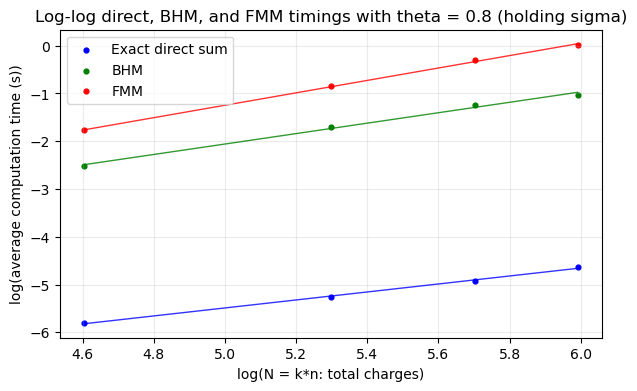

Direct gradient: 0.83635998405971
Direct PMCC: 0.9992659612882094
BHM gradient: 1.092145631429618
BHM PMCC: 0.9967639502917112
FMM gradient: 1.299435829206938
FMM PMCC: 0.9992167658590618


In [34]:
# Log-log plot for the sigma=0.03, threshold-k benchmark with separate lines of best fit.
sigma_003_k_threshold_log_N_values = np.log([result["N"] for result in sigma_003_k_threshold_benchmark_results])
sigma_003_k_threshold_log_direct_times = np.log([result["direct_average_time_seconds"] for result in sigma_003_k_threshold_benchmark_results])
sigma_003_k_threshold_log_bhm_times = np.log([result["bhm_average_time_seconds"] for result in sigma_003_k_threshold_benchmark_results])
sigma_003_k_threshold_log_fmm_times = np.log([result["fmm_average_time_seconds"] for result in sigma_003_k_threshold_benchmark_results])

sigma_003_k_threshold_direct_log_regression = scipy.stats.linregress(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_log_direct_times)
sigma_003_k_threshold_bhm_log_regression = scipy.stats.linregress(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_log_bhm_times)
sigma_003_k_threshold_fmm_log_regression = scipy.stats.linregress(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_log_fmm_times)

sigma_003_k_threshold_direct_line_of_best_fit = sigma_003_k_threshold_direct_log_regression.intercept + sigma_003_k_threshold_direct_log_regression.slope * sigma_003_k_threshold_log_N_values
sigma_003_k_threshold_bhm_line_of_best_fit = sigma_003_k_threshold_bhm_log_regression.intercept + sigma_003_k_threshold_bhm_log_regression.slope * sigma_003_k_threshold_log_N_values
sigma_003_k_threshold_fmm_line_of_best_fit = sigma_003_k_threshold_fmm_log_regression.intercept + sigma_003_k_threshold_fmm_log_regression.slope * sigma_003_k_threshold_log_N_values

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_log_direct_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_log_bhm_times, s=12, color="green", label="BHM")
ax.scatter(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_log_fmm_times, s=12, color="red", label="FMM")
ax.plot(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_direct_line_of_best_fit, color="blue", linewidth=1, alpha=0.8)
ax.plot(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_bhm_line_of_best_fit, color="green", linewidth=1, alpha=0.8)
ax.plot(sigma_003_k_threshold_log_N_values, sigma_003_k_threshold_fmm_line_of_best_fit, color="red", linewidth=1, alpha=0.8)
ax.set_xlabel("log(N = k*n: total charges)")
ax.set_ylabel("log(average computation time (s))")
ax.set_title("Log-log direct, BHM, and FMM timings with theta = 0.8 (holding sigma)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

print(f"Direct gradient: {sigma_003_k_threshold_direct_log_regression.slope}")
print(f"Direct PMCC: {sigma_003_k_threshold_direct_log_regression.rvalue}")
print(f"BHM gradient: {sigma_003_k_threshold_bhm_log_regression.slope}")
print(f"BHM PMCC: {sigma_003_k_threshold_bhm_log_regression.rvalue}")
print(f"FMM gradient: {sigma_003_k_threshold_fmm_log_regression.slope}")
print(f"FMM PMCC: {sigma_003_k_threshold_fmm_log_regression.rvalue}")


FMM and BHM models are improving, but direct summing still maintains optimal growth rates at still sub-linear. Clearly this data should not be taken seriously as evidence in terms of large `N` asymptotics with such few data points and a small minimum, but it still indicates of weakness in BHM and FFM at low `N`.

A representative illustration is given below.

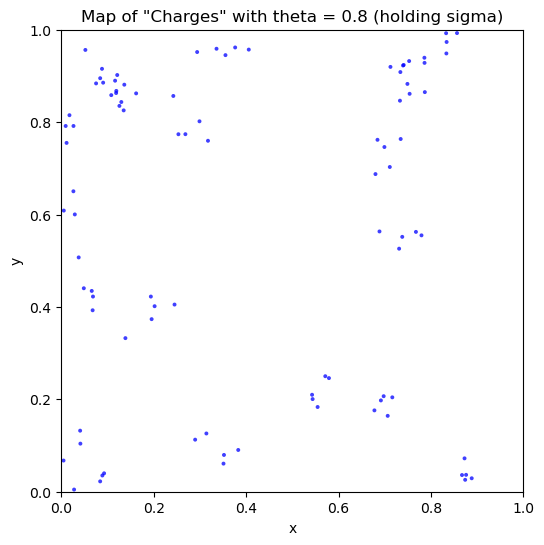

In [36]:
# Generate and plot a map using the sigma=0.03, threshold-k configuration.
sigma_003_k_threshold_map_n = 5
sigma_003_k_threshold_map_original_points = rng.uniform(
    0.0,
    1.0,
    size=(sigma_003_k_threshold_k, 2),
)
sigma_003_k_threshold_map_offsets = rng.normal(
    loc=0.0,
    scale=sigma_003_k_threshold_sigma,
    size=(sigma_003_k_threshold_k, sigma_003_k_threshold_map_n, 2),
)
sigma_003_k_threshold_map_points = (
    sigma_003_k_threshold_map_original_points[:, np.newaxis, :]
    + sigma_003_k_threshold_map_offsets
).reshape(sigma_003_k_threshold_k * sigma_003_k_threshold_map_n, 2)

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")
ax.scatter(
    sigma_003_k_threshold_map_points[:, 0],
    sigma_003_k_threshold_map_points[:, 1],
    s=8,
    c="blue",
    alpha=0.75,
    edgecolors="none",
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title('Map of "Charges" with theta = 0.8 (holding sigma)')
ax.grid(False)
plt.show()


We now test the alternative models in a pseudouniform scenario by increasing `sigma` greatly. We now discard the `theta = 6*sigma*sqrt(k)` formula as this is specifically engineered to protect clusters. We set `sigma = 0.15` so that `3*sigma = 0.45` is just under half the width of the square. `k` is reset to 5 and `theta = 0.8` is fixed, as this provided the closest possible growth rates of BHM and FMM to the direct method with acceptable error. We return to testing evey `n` from `n = 10` to 100 in 10s.

In [37]:
# Repeat the direct, BHM, and FMM benchmark with k=5, sigma=0.15, and theta=0.8.
sigma_015_theta_08_k = 5
sigma_015_theta_08_sigma = 0.15
sigma_015_theta_08 = 0.8
sigma_015_theta_08_n_values = np.arange(10, 101, 10)
sigma_015_theta_08_num_random_generations = 10
max_order = 3

sigma_015_theta_08_benchmark_results = []

for n_for_benchmark in sigma_015_theta_08_n_values:
    direct_generation_times = []
    bhm_generation_times = []
    fmm_generation_times = []
    direct_pairwise_sums = []
    bhm_pairwise_sums = []
    fmm_pairwise_sums = []

    for _ in range(sigma_015_theta_08_num_random_generations):
        # Generate one new map with k=5 and sigma=0.15, then use it for all algorithms.
        sigma_015_theta_08_original_points = rng.uniform(
            0.0,
            1.0,
            size=(sigma_015_theta_08_k, 2),
        )
        sigma_015_theta_08_offsets = rng.normal(
            loc=0.0,
            scale=sigma_015_theta_08_sigma,
            size=(sigma_015_theta_08_k, n_for_benchmark, 2),
        )
        sigma_015_theta_08_blue_points = (
            sigma_015_theta_08_original_points[:, np.newaxis, :]
            + sigma_015_theta_08_offsets
        ).reshape(sigma_015_theta_08_k * n_for_benchmark, 2)

        # Time the exact direct pairwise sum on this map.
        start_time = perf_counter()
        direct_pairwise_sum = sum_pairwise_kernel(
            sigma_015_theta_08_blue_points,
            inverse_distance_kernel,
        )
        direct_elapsed_time = perf_counter() - start_time
        direct_generation_times.append(direct_elapsed_time)
        direct_pairwise_sums.append(direct_pairwise_sum)

        # Time the Barnes-Hut approximation on the same map.
        start_time = perf_counter()
        bhm_pairwise_sum = barnes_hut_pairwise_kernel_sum(
            sigma_015_theta_08_blue_points,
            inverse_distance_kernel,
            theta=sigma_015_theta_08,
            leaf_size=8,
        )
        bhm_elapsed_time = perf_counter() - start_time
        bhm_generation_times.append(bhm_elapsed_time)
        bhm_pairwise_sums.append(bhm_pairwise_sum)

        # Time the FMM-style approximation on the same map.
        start_time = perf_counter()
        fmm_pairwise_sum = fast_multipole_inverse_distance_sum(
            sigma_015_theta_08_blue_points,
            theta=sigma_015_theta_08,
            max_order=max_order,
            leaf_size=8,
        )
        fmm_elapsed_time = perf_counter() - start_time
        fmm_generation_times.append(fmm_elapsed_time)
        fmm_pairwise_sums.append(fmm_pairwise_sum)

    sigma_015_theta_08_benchmark_results.append(
        {
            "n": int(n_for_benchmark),
            "N": int(sigma_015_theta_08_k * n_for_benchmark),
            "sigma": float(sigma_015_theta_08_sigma),
            "k": int(sigma_015_theta_08_k),
            "theta": float(sigma_015_theta_08),
            "direct_average_time_seconds": float(np.mean(direct_generation_times)),
            "direct_all_times_seconds": direct_generation_times,
            "direct_all_pairwise_sums": [float(value) for value in direct_pairwise_sums],
            "direct_last_pairwise_sum": float(direct_pairwise_sum),
            "bhm_average_time_seconds": float(np.mean(bhm_generation_times)),
            "bhm_all_times_seconds": bhm_generation_times,
            "bhm_all_pairwise_sums": [float(value) for value in bhm_pairwise_sums],
            "bhm_last_pairwise_sum": float(bhm_pairwise_sum),
            "fmm_average_time_seconds": float(np.mean(fmm_generation_times)),
            "fmm_all_times_seconds": fmm_generation_times,
            "fmm_all_pairwise_sums": [float(value) for value in fmm_pairwise_sums],
            "fmm_last_pairwise_sum": float(fmm_pairwise_sum),
        }
    )


Largest n = 100; N = 500
trial         direct sum            BHM sum    BHM frac. error            FMM sum    FMM frac. error
-----------------------------------------------------------------------------------------------------
    1      454195.368116      451179.752777       6.639467e-03      454031.706570       3.603329e-04
    2      295136.445811      293241.426626       6.420824e-03      295035.898510       3.406807e-04
    3      344401.067571      342387.237337       5.847340e-03      344272.283036       3.739377e-04
    4      393485.472481      390717.865686       7.033568e-03      393347.911765       3.495954e-04
    5      464773.348627      461177.717170       7.736312e-03      464586.935676       4.010836e-04
    6      361350.827835      359210.545669       5.923003e-03      361239.171550       3.089969e-04
    7      355425.282868      352749.669911       7.527920e-03      355283.518213       3.988592e-04
    8      332333.763567      330298.345077       6.124621e-03   

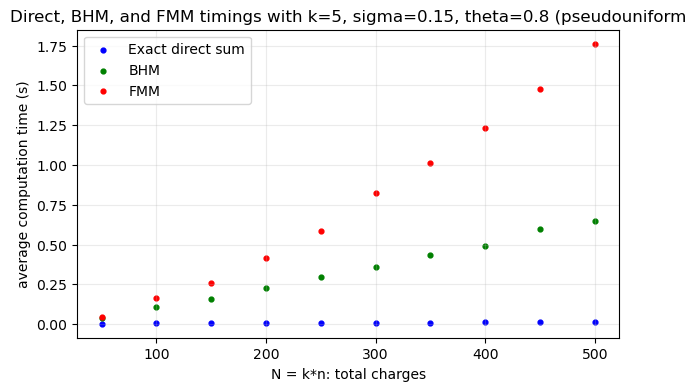

In [39]:
# Tabulate and plot the k=5, sigma=0.15, theta=0.8 benchmark results.
sigma_015_theta_08_largest_n_result = max(sigma_015_theta_08_benchmark_results, key=lambda result: result["n"])
sigma_015_theta_08_direct_sums = np.asarray(sigma_015_theta_08_largest_n_result["direct_all_pairwise_sums"])
sigma_015_theta_08_bhm_sums = np.asarray(sigma_015_theta_08_largest_n_result["bhm_all_pairwise_sums"])
sigma_015_theta_08_fmm_sums = np.asarray(sigma_015_theta_08_largest_n_result["fmm_all_pairwise_sums"])
sigma_015_theta_08_bhm_fractional_errors = np.abs(sigma_015_theta_08_bhm_sums - sigma_015_theta_08_direct_sums) / np.abs(sigma_015_theta_08_direct_sums)
sigma_015_theta_08_fmm_fractional_errors = np.abs(sigma_015_theta_08_fmm_sums - sigma_015_theta_08_direct_sums) / np.abs(sigma_015_theta_08_direct_sums)

print(f"Largest n = {sigma_015_theta_08_largest_n_result['n']}; N = {sigma_015_theta_08_largest_n_result['N']}")
print(
    f"{'trial':>5} "
    f"{'direct sum':>18} "
    f"{'BHM sum':>18} "
    f"{'BHM frac. error':>18} "
    f"{'FMM sum':>18} "
    f"{'FMM frac. error':>18}"
)
print("-" * 101)
for trial_index, (direct_sum, bhm_sum, bhm_error, fmm_sum, fmm_error) in enumerate(
    zip(
        sigma_015_theta_08_direct_sums,
        sigma_015_theta_08_bhm_sums,
        sigma_015_theta_08_bhm_fractional_errors,
        sigma_015_theta_08_fmm_sums,
        sigma_015_theta_08_fmm_fractional_errors,
    ),
    start=1,
):
    print(
        f"{trial_index:5d} "
        f"{direct_sum:18.6f} "
        f"{bhm_sum:18.6f} "
        f"{bhm_error:18.6e} "
        f"{fmm_sum:18.6f} "
        f"{fmm_error:18.6e}"
    )

print("Averages over these largest-n trials:")
print(f"Average direct sum: {np.mean(sigma_015_theta_08_direct_sums)}")
print(f"Average BHM sum: {np.mean(sigma_015_theta_08_bhm_sums)}")
print(f"Average BHM fractional error: {np.mean(sigma_015_theta_08_bhm_fractional_errors)}")
print(f"Average FMM sum: {np.mean(sigma_015_theta_08_fmm_sums)}")
print(f"Average FMM fractional error: {np.mean(sigma_015_theta_08_fmm_fractional_errors)}")
print()

print(f"sigma = {sigma_015_theta_08_sigma}")
print(f"k = {sigma_015_theta_08_k}")
print(f"theta = {sigma_015_theta_08}")
print(
    f"{'N = k*n':>10} "
    f"{'Direct average (s)':>20} "
    f"{'BHM average (s)':>18} "
    f"{'FMM average (s)':>18}"
)
print("-" * 72)
for result in sigma_015_theta_08_benchmark_results:
    print(
        f"{result['N']:10d} "
        f"{result['direct_average_time_seconds']:20.6f} "
        f"{result['bhm_average_time_seconds']:18.6f} "
        f"{result['fmm_average_time_seconds']:18.6f}"
    )

sigma_015_theta_08_plot_N_values = [result["N"] for result in sigma_015_theta_08_benchmark_results]
sigma_015_theta_08_direct_average_times = [result["direct_average_time_seconds"] for result in sigma_015_theta_08_benchmark_results]
sigma_015_theta_08_bhm_average_times = [result["bhm_average_time_seconds"] for result in sigma_015_theta_08_benchmark_results]
sigma_015_theta_08_fmm_average_times = [result["fmm_average_time_seconds"] for result in sigma_015_theta_08_benchmark_results]

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(sigma_015_theta_08_plot_N_values, sigma_015_theta_08_direct_average_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(sigma_015_theta_08_plot_N_values, sigma_015_theta_08_bhm_average_times, s=12, color="green", label="BHM")
ax.scatter(sigma_015_theta_08_plot_N_values, sigma_015_theta_08_fmm_average_times, s=12, color="red", label="FMM")
ax.set_xlabel("N = k*n: total charges")
ax.set_ylabel("average computation time (s)")
ax.set_title("Direct, BHM, and FMM timings with k=5, sigma=0.15, theta=0.8 (pseudouniform")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


The consistent order of magnitude in fractional error for BHM and FMM at ${10}^{-4}$ and ${10}^{-3}$ respectively as `theta` has remained consistent suggests that `theta` is the key determiner of fractional error, and that the other parameters like `sigma` and `k` are more important on determining times taken.

As expected, the increased variance and tendency to a uniform distribution heavily hampered due to the lack of a well defined `s` to allow for an accurate judgement of `theta`. In this experiment, `theta` was selected simply as the most lenient possible parameter for a general running of the method. BHM increased at `N = 500` from 0.60 to 0.64, and FMM from 1.64 to 1.76 when compared to the "`theta = 0.8`, holding k" trial.

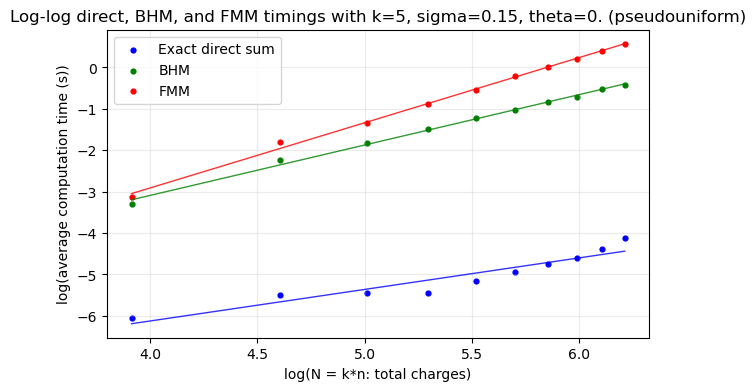

Direct gradient: 0.7613664033952359
Direct PMCC: 0.946531595333928
BHM gradient: 1.2159140363573193
BHM PMCC: 0.9980112903587753
FMM gradient: 1.5727304569388205
FMM PMCC: 0.9985003608189639


In [40]:
# Log-log plot for the k=5, sigma=0.15, theta=0.8 benchmark with separate lines of best fit.
sigma_015_theta_08_log_N_values = np.log([result["N"] for result in sigma_015_theta_08_benchmark_results])
sigma_015_theta_08_log_direct_times = np.log([result["direct_average_time_seconds"] for result in sigma_015_theta_08_benchmark_results])
sigma_015_theta_08_log_bhm_times = np.log([result["bhm_average_time_seconds"] for result in sigma_015_theta_08_benchmark_results])
sigma_015_theta_08_log_fmm_times = np.log([result["fmm_average_time_seconds"] for result in sigma_015_theta_08_benchmark_results])

sigma_015_theta_08_direct_log_regression = scipy.stats.linregress(sigma_015_theta_08_log_N_values, sigma_015_theta_08_log_direct_times)
sigma_015_theta_08_bhm_log_regression = scipy.stats.linregress(sigma_015_theta_08_log_N_values, sigma_015_theta_08_log_bhm_times)
sigma_015_theta_08_fmm_log_regression = scipy.stats.linregress(sigma_015_theta_08_log_N_values, sigma_015_theta_08_log_fmm_times)

sigma_015_theta_08_direct_line_of_best_fit = sigma_015_theta_08_direct_log_regression.intercept + sigma_015_theta_08_direct_log_regression.slope * sigma_015_theta_08_log_N_values
sigma_015_theta_08_bhm_line_of_best_fit = sigma_015_theta_08_bhm_log_regression.intercept + sigma_015_theta_08_bhm_log_regression.slope * sigma_015_theta_08_log_N_values
sigma_015_theta_08_fmm_line_of_best_fit = sigma_015_theta_08_fmm_log_regression.intercept + sigma_015_theta_08_fmm_log_regression.slope * sigma_015_theta_08_log_N_values

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.scatter(sigma_015_theta_08_log_N_values, sigma_015_theta_08_log_direct_times, s=12, color="blue", label="Exact direct sum")
ax.scatter(sigma_015_theta_08_log_N_values, sigma_015_theta_08_log_bhm_times, s=12, color="green", label="BHM")
ax.scatter(sigma_015_theta_08_log_N_values, sigma_015_theta_08_log_fmm_times, s=12, color="red", label="FMM")
ax.plot(sigma_015_theta_08_log_N_values, sigma_015_theta_08_direct_line_of_best_fit, color="blue", linewidth=1, alpha=0.8)
ax.plot(sigma_015_theta_08_log_N_values, sigma_015_theta_08_bhm_line_of_best_fit, color="green", linewidth=1, alpha=0.8)
ax.plot(sigma_015_theta_08_log_N_values, sigma_015_theta_08_fmm_line_of_best_fit, color="red", linewidth=1, alpha=0.8)
ax.set_xlabel("log(N = k*n: total charges)")
ax.set_ylabel("log(average computation time (s))")
ax.set_title("Log-log direct, BHM, and FMM timings with k=5, sigma=0.15, theta=0. (pseudouniform)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

print(f"Direct gradient: {sigma_015_theta_08_direct_log_regression.slope}")
print(f"Direct PMCC: {sigma_015_theta_08_direct_log_regression.rvalue}")
print(f"BHM gradient: {sigma_015_theta_08_bhm_log_regression.slope}")
print(f"BHM PMCC: {sigma_015_theta_08_bhm_log_regression.rvalue}")
print(f"FMM gradient: {sigma_015_theta_08_fmm_log_regression.slope}")
print(f"FMM PMCC: {sigma_015_theta_08_fmm_log_regression.rvalue}")


At the scales examined (`N < 500`), the direct method has been the only method growing sublinear in `N` in all trials consistently.

An illustration of this setup (pesudouniform) is given below. Due to the high variance, many points are expected to fall outside the borders of a 1 by 1 square. Hence we are showing a square with the same centre, but a 3 by 3 square instead.

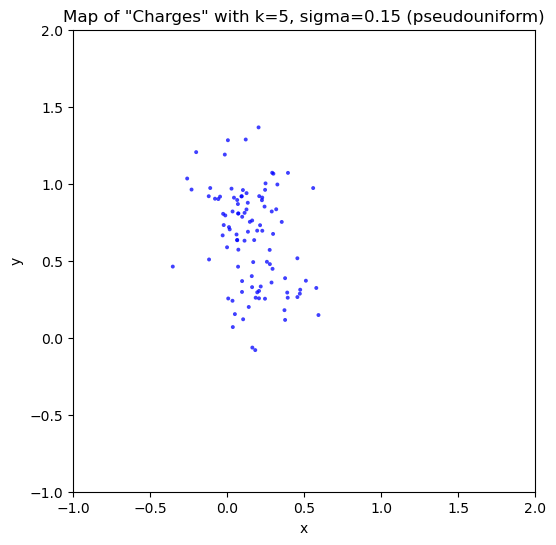

In [41]:
# Generate and plot a 3 by 3 map centered at (0.5, 0.5) for k=5, sigma=0.15, n=20.
sigma_015_theta_08_map_n = 20
sigma_015_theta_08_map_original_points = rng.uniform(
    0.0,
    1.0,
    size=(sigma_015_theta_08_k, 2),
)
sigma_015_theta_08_map_offsets = rng.normal(
    loc=0.0,
    scale=sigma_015_theta_08_sigma,
    size=(sigma_015_theta_08_k, sigma_015_theta_08_map_n, 2),
)
sigma_015_theta_08_map_points = (
    sigma_015_theta_08_map_original_points[:, np.newaxis, :]
    + sigma_015_theta_08_map_offsets
).reshape(sigma_015_theta_08_k * sigma_015_theta_08_map_n, 2)

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")
ax.scatter(
    sigma_015_theta_08_map_points[:, 0],
    sigma_015_theta_08_map_points[:, 1],
    s=8,
    c="blue",
    alpha=0.75,
    edgecolors="none",
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title('Map of "Charges" with k=5, sigma=0.15 (pseudouniform)')
ax.grid(False)
plt.show()


Miscellaneous Points Before Continuing:

FMM has consistently ranked as the time expensive algorithm in all setups. It should be emphasized at this point the choice was made to perform third order expansions (octupoles), which some may consider more detail than necessary and contributing to unecessary time expense. However, lowering the expanded-to order would leave the possibility of cancellation of lower order moments and neglecting key higher order moments significantly contributing to the answer. This is also a key flaw of BHM, so lowering the order too much would not leave enough gap between the two methods for a distinct comparison. This is evident in the demonstrably 10 to 100 times better fractional error using FMM as compared to BHM. Prioritizing one of time expense or accuracy over the other may be a cruical detail to ponder when choosing a method. It is likely that lowering the order of the expansion would lead to a faster algorithm.

There exists potentials where other methods are clearly superior due to algebraic methods. One key example of this is when the kernel is already a polynomial; for instance $|\mathbf{r}-\mathbf{r'}|^2$. When rewriting this term as a dot product, this term can easily be rewritten as a function of both the sum of the squared magnitudes of the position vectors, and the squared magnitude of the sum of the position vectors. This does not concern pairs and is evidently `O(N)`. Another way of viewing the same fact is that the multipole expansion of this kernel is finite. This means in this case, FMM makes good on its best promise of `O(N)` and becomes the dominant method - though even still it may not be the most effective if `N` is small enough that direct summing remains sub linear. It also is worth saying that such a potential which goes to infinity as its argument goes to infinity is unlikely to be physical in many practical scenarios, and may lead to confusing dynamics.

This report has focused on cluster setups due to these setups being the best possible set up for BHM and FMM, allowing for good indications for the selection of `theta`. However, if `n` is very large and / or `sigma` is really small, the cluster may be better off being approximated by a continous charge density function. In this case, continuous mathematics becomes a viable tool and may be more likely to produce a result (potentially even symbolic) than an intense computation method. It also gives justification for focusing the report on lower `n`/`N` values.

In cases of very fast decaying potentials (e.g. Lenard-Jones type potential $\frac{1}{|\mathbf{r}-\mathbf{r'}|^6}$), far field interactions are likely to be immaterial. In these cases, if an accurate answer is demanded, it may be that none of the above methods are the optimal option, and that Verlet lists or cell lists may be optimal.